In [1]:
!pip install lime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss



df = pd.read_csv("email.csv")
df

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=7603b22f61477741e14db57e1f5e51dfad348ee5cd96d6b017055e1e40347883
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...
...,...,...,...,...,...,...,...,...,...,...,...
781810,{E4A7-K0YN86DN-2389ECKD},05/20/2010 11:16:27,IIW0249,PC-0843,Glass-Matthew@aol.com,Igor.I.Ward@comcast.net,NaN,Igor.I.Ward@comcast.net,30117,0,thry quoted twelve among has each towed rule d...
781811,{O4E4-V0BX75OT-8883YMAG},05/20/2010 11:16:27,MES0407,PC-8827,Herman.Ian.Abbott@dtaa.com,NaN,NaN,Minerva.Emerald.Solomon@dtaa.com,35875,0,called craftsmen build thomas damaged stored e...
781812,{U6M5-A0SA71DG-5475AXIA},05/20/2010 11:16:29,CSB0080,PC-0731,Bryar_Sweet@bellsouth.net,NaN,NaN,Catherine_Bullock@comcast.net,22351,0,hence major perpendicular peculiar synonymousl...
781813,{P1S0-W2IC21HR-6253JZFH},05/20/2010 11:16:32,CCR0863,PC-7342,Zeph_Wilkerson@yahoo.com,NaN,NaN,Charde_Rasmussen@sbcglobal.net,39317,0,late distant york normal according colonies de...


## 1. Load and Preprocess Data

In [2]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Fill missing vals
df.fillna('', inplace=True)

In [3]:
# Label encoding for categorical columns
le = LabelEncoder()
for col in ['user', 'pc', 'to', 'cc', 'bcc', 'from']:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},2010-01-02 07:11:45,588,553,57273,41257,0,1239,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},2010-01-02 07:12:16,675,665,168748,0,0,1258,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},2010-01-02 07:13:00,588,553,173967,0,0,1240,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},2010-01-02 07:13:17,588,553,119644,0,0,1240,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},2010-01-02 07:13:28,675,665,27890,0,444,1258,17319,0,this kmh october holliswood number advised unu...


## 2. Exploratory Data Analysis (EDA)

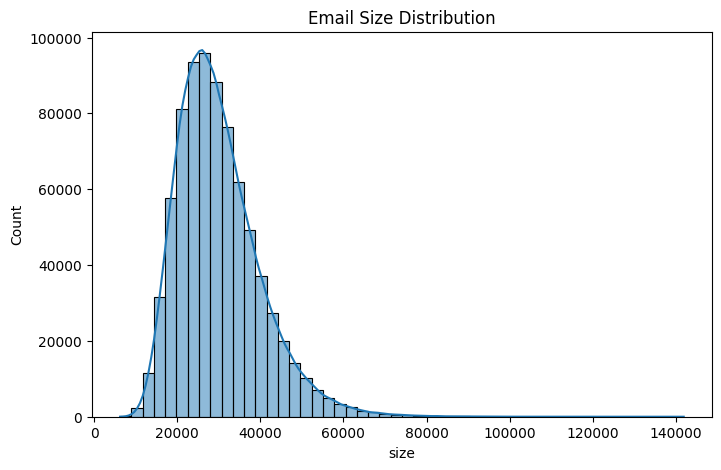

In [4]:
#size dist
plt.figure(figsize=(8,5))
sns.histplot(df['size'], bins=50, kde=True)
plt.title("Email Size Distribution")
plt.show()


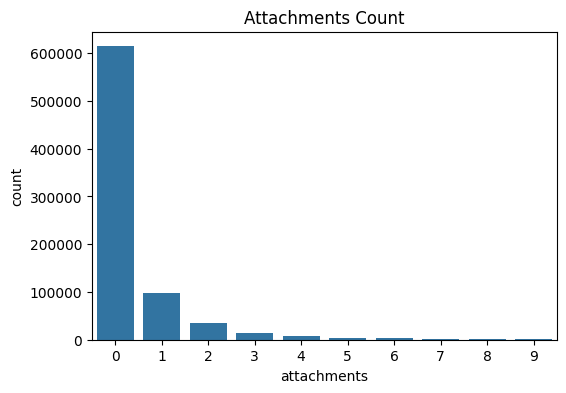

In [5]:
#Num ofattachments
plt.figure(figsize=(6,4))
sns.countplot(x='attachments', data=df)
plt.title("Attachments Count")
plt.show()


## 3. Generate Labels (Rule-Based)

In [6]:
# Feature Engineering from 'date'
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday
df['month'] = df['date'].dt.month
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

# feature selection
df.drop(columns=['date', 'to', 'cc', 'from'], inplace=True)


In [7]:
# Create a label based on 'bcc' and 'size' as suspicious
df['size'] = pd.to_numeric(df['size'], errors='coerce')
df['size'] = df['size'].fillna(0)
df['is_malicious'] = ((df['bcc'].astype(str).astype(int) > 0) & (df['size'] > 50000)).astype(int)

print(df['is_malicious'].value_counts())

is_malicious
0    776605
1      5210
Name: count, dtype: int64


In [8]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

features = df.select_dtypes(include=['number', 'bool']).columns.tolist()
features.remove('is_malicious')

X = df[features]
y = df['is_malicious']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 4. XGBoost Model MOHAMED TAREK 202201058

In [10]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

#Cross-valid for eval
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val_results = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print(f"Cross-validation results: {cross_val_results}")
print(f"Mean cross-validation score: {cross_val_results.mean()}")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:34:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:34:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:34:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:34:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:34:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Cross-validation results: [0.99962267 0.99969302 0.99964186 0.99961628 0.99966105]
Mean cross-validation score: 0.9996469753074576


In [11]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:34:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[[232959     45]
 [    42   1499]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    233004
           1       0.97      0.97      0.97      1541

    accuracy                           1.00    234545
   macro avg       0.99      0.99      0.99    234545
weighted avg       1.00      1.00      1.00    234545



In [12]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

train_loss = log_loss(y_train, model.predict_proba(X_train)[:, 1])
test_loss = log_loss(y_test, model.predict_proba(X_test)[:, 1])

print(f"Training Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")
print(f"Training Log Loss: {train_loss}")
print(f"Test Log Loss: {test_loss}")


Training Accuracy: 0.9999981727483692
Test Accuracy: 0.9996290690485834
Training Log Loss: 8.090128506982677e-05
Test Log Loss: 0.0008592711278986614


## 5. Feature Importance

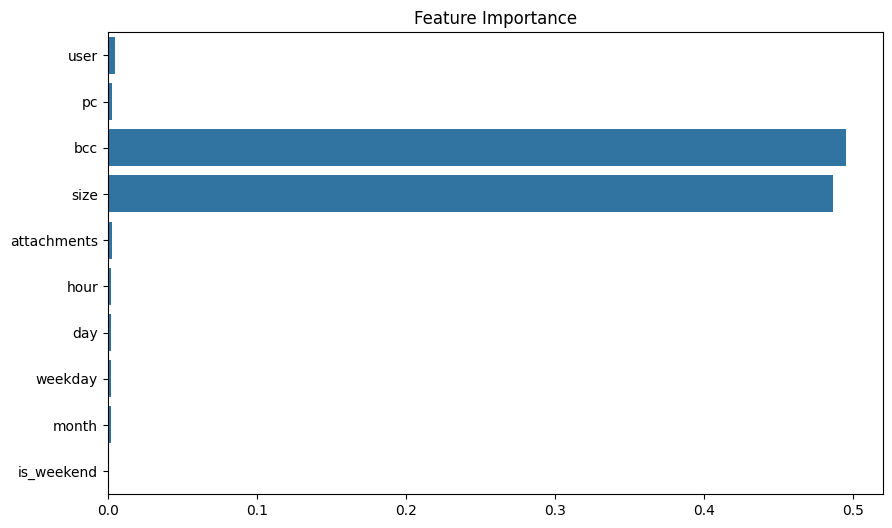

In [13]:
# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x=model.feature_importances_, y=features)
plt.title("Feature Importance")
plt.show()


# ***LIME***

In [14]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns.tolist(),
    class_names=['Benign', 'Threat'],
    mode='classification'
)
i =31
exp = explainer.explain_instance(data_row=X_test.iloc[i].values,predict_fn=model.predict_proba)

exp.show_in_notebook()

***The LIME plot shows that 'size' and 'hour' contributed most to the model's prediction of a benign email.***

# ***PFI***

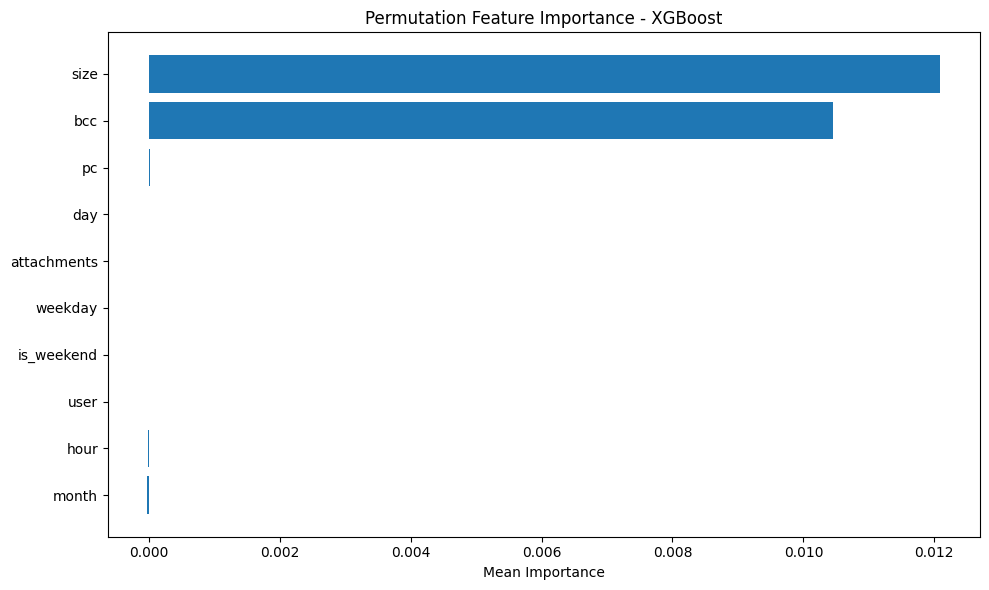

In [15]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

#permutation
pfi_result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

sorted_idx = pfi_result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[sorted_idx], pfi_result.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance - XGBoost")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()


***'Size' and 'bcc' had the largest drop in accuracy when permuted, indicating their high importance.***

# ***SHAP***

In [16]:
import shap

#explainer
explainer_shap = shap.TreeExplainer(model)
shap_values = explainer_shap.shap_values(X_test)

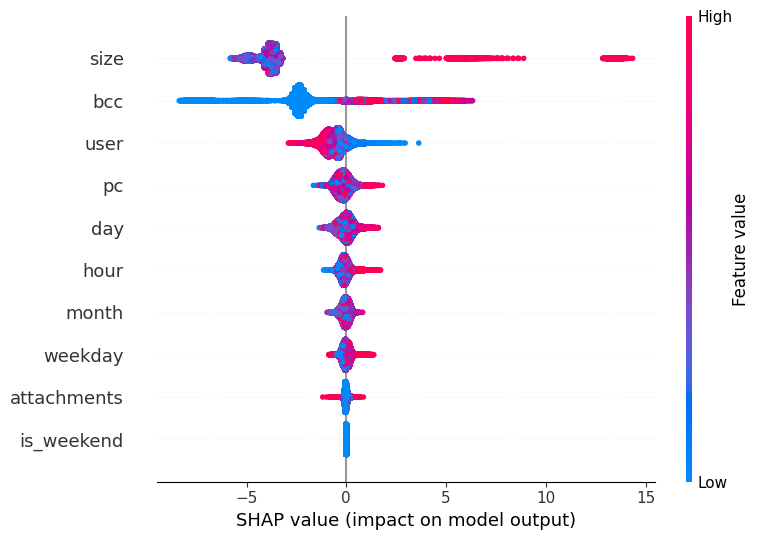

In [17]:
shap.summary_plot(shap_values, X_test)

### **SHAP confirms that 'size' and 'bcc' have the strongest impact on model predictions.**

# **LOFO**

In [18]:
from sklearn.metrics import accuracy_score

base_pred = model.predict(X_test)
base_acc = accuracy_score(y_test, base_pred)

lofo_scores = {}

for col in X_train.columns:
    X_train_lofo = X_train.drop(columns=[col])
    X_test_lofo = X_test.drop(columns=[col])

    model_lofo = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    model_lofo.fit(X_train_lofo, y_train)
    lofo_pred = model_lofo.predict(X_test_lofo)
    lofo_acc = accuracy_score(y_test, lofo_pred)

    lofo_scores[col] = base_acc - lofo_acc

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:39:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:39:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:40:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:40:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [22:40:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

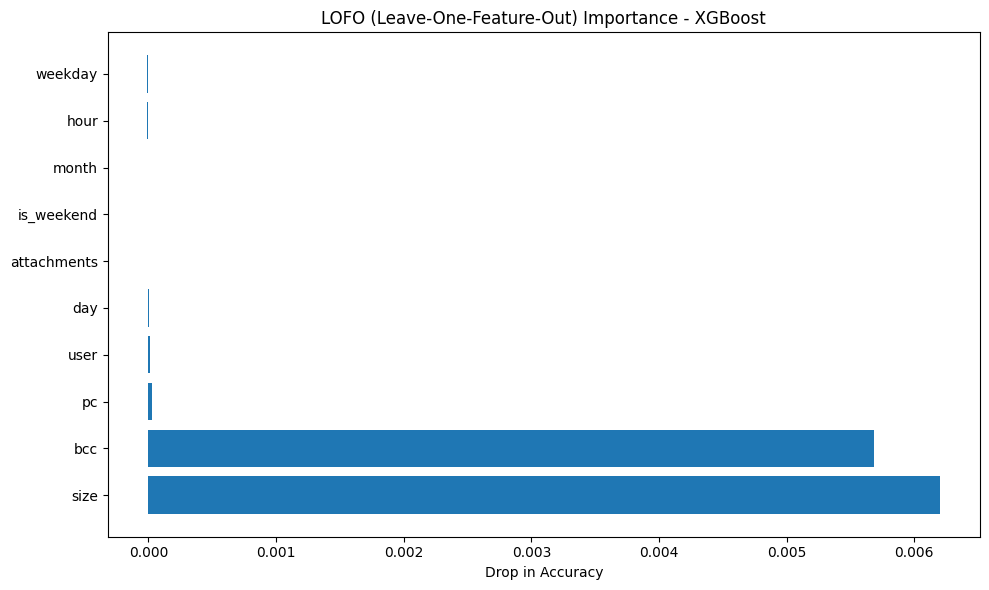

In [19]:
sorted_lofo = dict(sorted(lofo_scores.items(), key=lambda item: item[1], reverse=True))
plt.figure(figsize=(10, 6))
plt.barh(list(sorted_lofo.keys()), list(sorted_lofo.values()))
plt.title("LOFO (Leave-One-Feature-Out) Importance - XGBoost")
plt.xlabel("Drop in Accuracy")
plt.tight_layout()
plt.show()

***Dropping 'size' or 'bcc' significantly reduces model accuracy, highlighting their influence.***

# ***ICE***

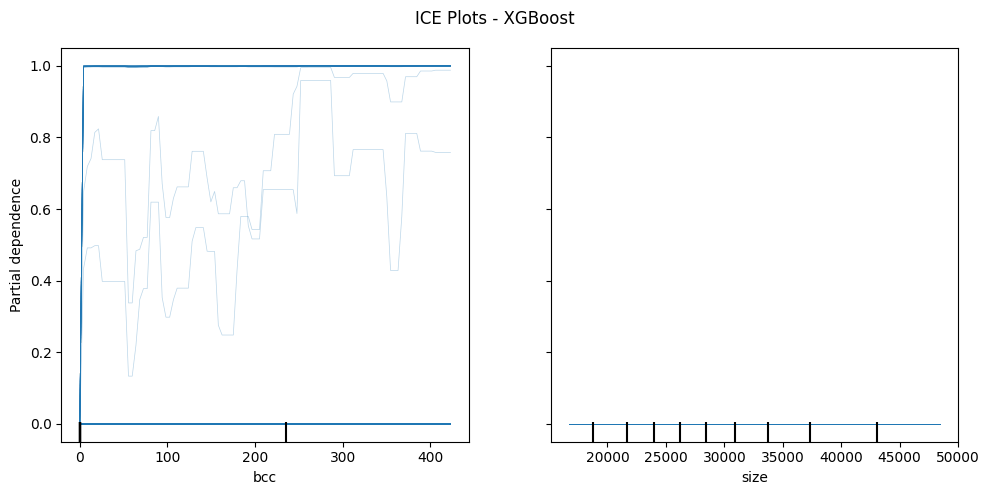

In [21]:
features_to_plot = ['bcc', 'size']

fig, ax = plt.subplots(figsize=(10, 5))
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=features_to_plot,
    kind='individual',
    ax=ax
)
plt.suptitle("ICE Plots - XGBoost")
plt.tight_layout()
plt.show()


*ICE curves show that predictions change steeply with 'bcc' and remain flat for most 'size' values.*